# 01 — Dataset Exploration & Exploratory Data Analysis
### AI-Powered Intelligent Hiring Assistant —# 
**Goal:** Understand the raw resume dataset before any cleaning or modeling — schema, data quality,
class balance, text characteristics, and skill vocabulary — so every later module (cleaning,
classification, semantic matching, RAG) is built on an accurate picture of the data.

**Dataset:** `data/raw/resumes dataset.jsonl` (Kaggle Resume Dataset, provided by Celebal CEI Program)


## 1. Imports & Load

In [1]:
import json
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 110

records = []
with open('../data/raw/resumes_dataset.jsonl') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Loaded {len(df):,} resumes with {df.shape[1]} columns")
df.head(3)


Loaded 3,500 resumes with 12 columns


,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 2014 102011 112013 ...,"City, State",jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary high...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary high...,Computer Science degree,jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary high...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 30 70 ...,"City, State",jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjama...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjama...,Computer Science degree,jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjama...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 2 052017 2 5 253 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years ...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years ...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years ...,ResumeAtlas


## 2. Schema & Data Types

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ResumeID    3500 non-null   str  
 1   Category    3500 non-null   str  
 2   Name        3500 non-null   str  
 3   Email       3500 non-null   str  
 4   Phone       3500 non-null   str  
 5   Location    3500 non-null   str  
 6   Summary     3500 non-null   str  
 7   Skills      3500 non-null   str  
 8   Experience  3500 non-null   str  
 9   Education   3500 non-null   str  
 10  Text        3500 non-null   str  
 11  Source      3500 non-null   str  
dtypes: str(12)
memory usage: 328.3 KB


## 3. Missing Values & Duplicate Analysis

In [3]:
print("Null counts:")
print(df.isnull().sum())

print("\nEmpty-string counts:")
for c in df.columns:
    print(f"  {c}: {(df[c].astype(str).str.strip()=='').sum()}")

print("\nDuplicate ResumeIDs:", df['ResumeID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate `Text` values:", df['Text'].duplicated().sum(),
      "(same narrative reused across different ResumeIDs/categories)")


Null counts:
ResumeID      0
Category      0
Name          0
Email         0
Phone         0
Location      0
Summary       0
Skills        0
Experience    0
Education     0
Text          0
Source        0
dtype: int64

Empty-string counts:
  ResumeID: 0
  Category: 0
  Name: 0
  Email: 0
  Phone: 0
  Location: 0
  Summary: 0
  Skills: 0
  Experience: 0
  Education: 0
  Text: 0
  Source: 0

Duplicate ResumeIDs: 0
Fully duplicate rows: 0
Duplicate `Text` values: 196 (same narrative reused across different ResumeIDs/categories)


**Finding:** No nulls or empty strings anywhere — but that's misleading. The dataset is a merge of two
very different sources (see Section 4), and one of them fills most fields with a repeated placeholder
rather than leaving them null. 196 resumes also share identical `Text` content with other rows.

## 4. Source Composition — the key structural finding

In [4]:
print(df['Source'].value_counts())
print()
for src in ['ResumeAtlas', 'Synthetic']:
    sub = df[df['Source'] == src]
    print(f"--- {src} (n={len(sub)}) ---")
    for col in ['Skills', 'Education', 'Email', 'Location']:
        print(f"  unique {col}: {sub[col].nunique()}")


Source
ResumeAtlas    2337
Synthetic      1163
Name: count, dtype: int64

--- ResumeAtlas (n=2337) ---
  unique Skills: 1
  unique Education: 1
  unique Email: 1
  unique Location: 1
--- Synthetic (n=1163) ---
  unique Skills: 918
  unique Education: 1159
  unique Email: 1160
  unique Location: 1163


**Critical finding:** `ResumeAtlas` (2,337 rows, 67%) has only **one unique value** for `Skills`,
`Education`, `Email`, and `Location` — they're placeholder text carried over from a template
(`"Python, SQL, Git, Linux"`, `"Computer Science degree"`, `"contact@email.com"`, `"City, State"`),
not real per-candidate data. Only the `Text` field is genuinely per-resume for this source.

`Synthetic` (1,163 rows, 33%) has realistic, diverse structured fields (918 distinct skill sets, 1,159
distinct education strings, etc.) — this is a generated dataset with real per-record structure.

**Practical implication for later modules:** the `Skills`/`Education`/`Location` columns are only
trustworthy for the Synthetic subset.# (Resume Parsing) will need to *extract* skills/education
from free text for the ResumeAtlas rows rather than relying on those columns.

## 5. Category Distribution

In [5]:
print("Number of unique categories:", df['Category'].nunique())
df['Category'].value_counts()


Number of unique categories: 36


Category
Java Developer               200
Python Developer             200
Data Science                 200
DevOps                       180
SQL Developer                180
Database                     150
Testing                      150
Web Designing                150
React Developer              150
Business Analyst             150
DotNet Developer             140
Software Developer           134
ETL Developer                120
Network Security Engineer    120
Full Stack Developer         102
SAP Developer                100
Digital Media                100
Cloud Engineer                92
Machine Learning Engineer     81
Frontend Developer            76
Backend Developer             76
AI Engineer                   71
Cybersecurity Analyst         66
QA Engineer                   61
Database Administrator        56
UI/UX Designer                51
Blockchain                    47
Site Reliability Engineer     46
Mobile Developer              46
System Administrator          40
T

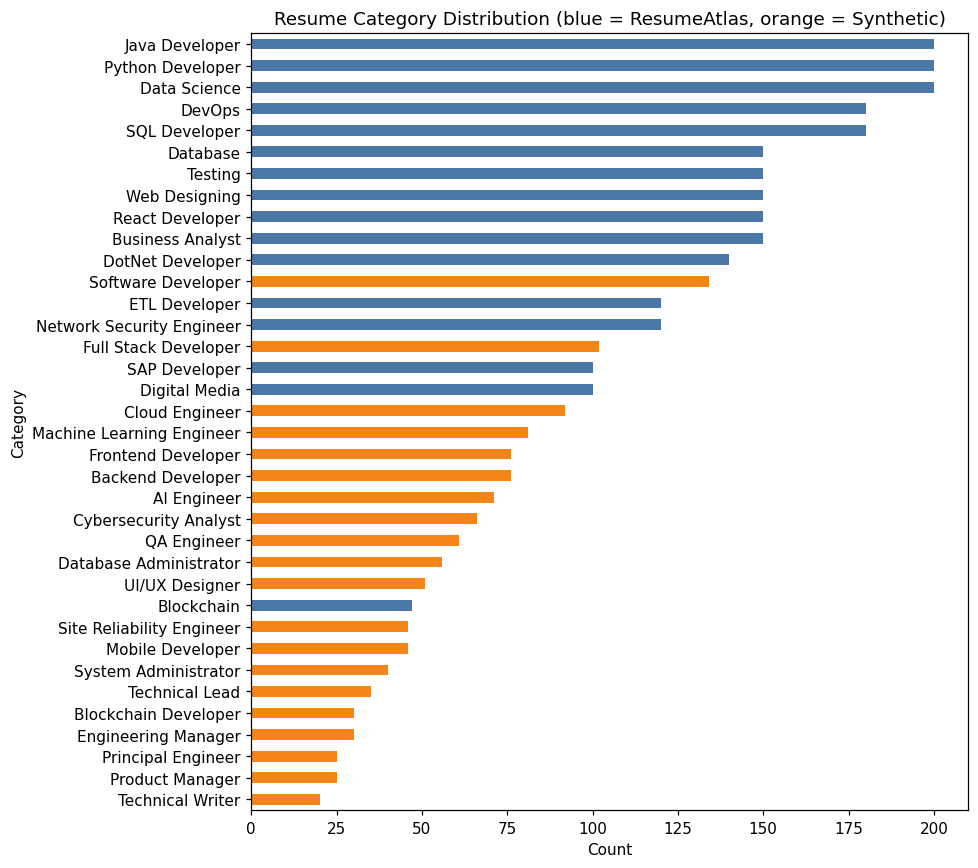

In [6]:
order = df['Category'].value_counts().index
ra_cats = set(df[df.Source == 'ResumeAtlas']['Category'])
colors = ['#4C78A8' if c in ra_cats else '#F58518' for c in order]

fig, ax = plt.subplots(figsize=(9, 8))
df['Category'].value_counts().loc[order].plot(kind='barh', ax=ax, color=colors)
ax.invert_yaxis()
ax.set_xlabel('Count')
ax.set_title('Resume Category Distribution (blue = ResumeAtlas, orange = Synthetic)')
plt.tight_layout()
plt.savefig('../reports/figures/01_category_distribution.png')
plt.show()


### 5.1 Category / Source overlap check

In [7]:
ra_cats = set(df[df.Source == 'ResumeAtlas']['Category'].unique())
syn_cats = set(df[df.Source == 'Synthetic']['Category'].unique())
print("ResumeAtlas categories:", len(ra_cats))
print("Synthetic categories:", len(syn_cats))
print("Overlap between the two sources:", ra_cats & syn_cats)


ResumeAtlas categories: 16
Synthetic categories: 20
Overlap between the two sources: set()


**Critical finding:** the two sources have **zero category overlap** — 16 categories appear only in
ResumeAtlas, 20 appear only in Synthetic. This means `Source` and `Category` are entirely confounded:
a classifier could reach high accuracy just by learning stylistic differences between the two sources
(e.g. text length, phrasing) instead of learning what actually distinguishes a Java Developer resume
from a DevOps resume. **# evaluation must control for this** — e.g. by checking whether
misclassifications cluster along source lines, and by not treating overall accuracy alone as proof the
model learned real signal.

## 6. Resume Length Analysis

In [8]:
df['text_len_words'] = df['Text'].str.split().str.len()
df['text_len_chars'] = df['Text'].str.len()

print(df['text_len_words'].describe())
print()
print(df.groupby('Source')['text_len_words'].describe())


count    3500.000000
mean      423.564857
std       360.679658
min        28.000000
25%       196.000000
50%       257.000000
75%       577.000000
max      6554.000000
Name: text_len_words, dtype: float64

              count        mean         std    min    25%    50%    75%  \
Source                                                                    
ResumeAtlas  2337.0  539.580231  391.982047   28.0  252.0  476.0  698.0   
Synthetic    1163.0  190.436801   37.054922  111.0  159.0  192.0  219.0   

                max  
Source               
ResumeAtlas  6554.0  
Synthetic     293.0  


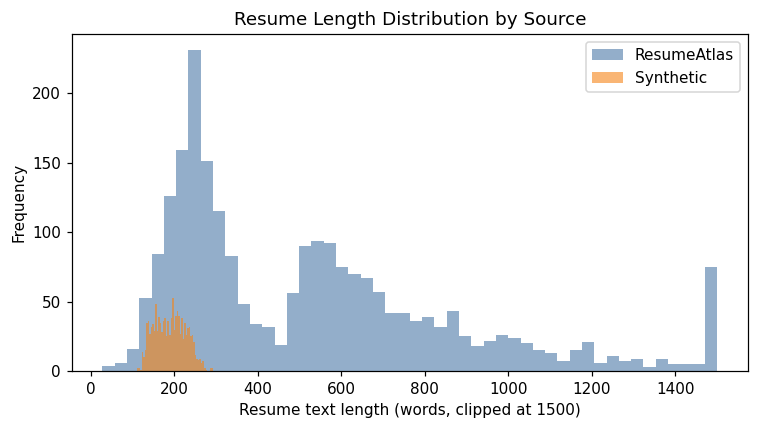

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for src, color in [('ResumeAtlas', '#4C78A8'), ('Synthetic', '#F58518')]:
    sub = df[df.Source == src]['text_len_words']
    ax.hist(sub.clip(upper=1500), bins=50, alpha=0.6, label=src, color=color)
ax.set_xlabel('Resume text length (words, clipped at 1500)')
ax.set_ylabel('Frequency')
ax.set_title('Resume Length Distribution by Source')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/03_text_length_distribution.png')
plt.show()


**Finding:** ResumeAtlas resumes average ~540 words with high variance (std ~392, max 6,554) —
real, messy scraped resumes of very different lengths. Synthetic resumes are tightly clustered
around ~190 words (std ~37) — templated generation. This length gap alone is a strong (undesirable)
signal a classifier could latch onto instead of content.

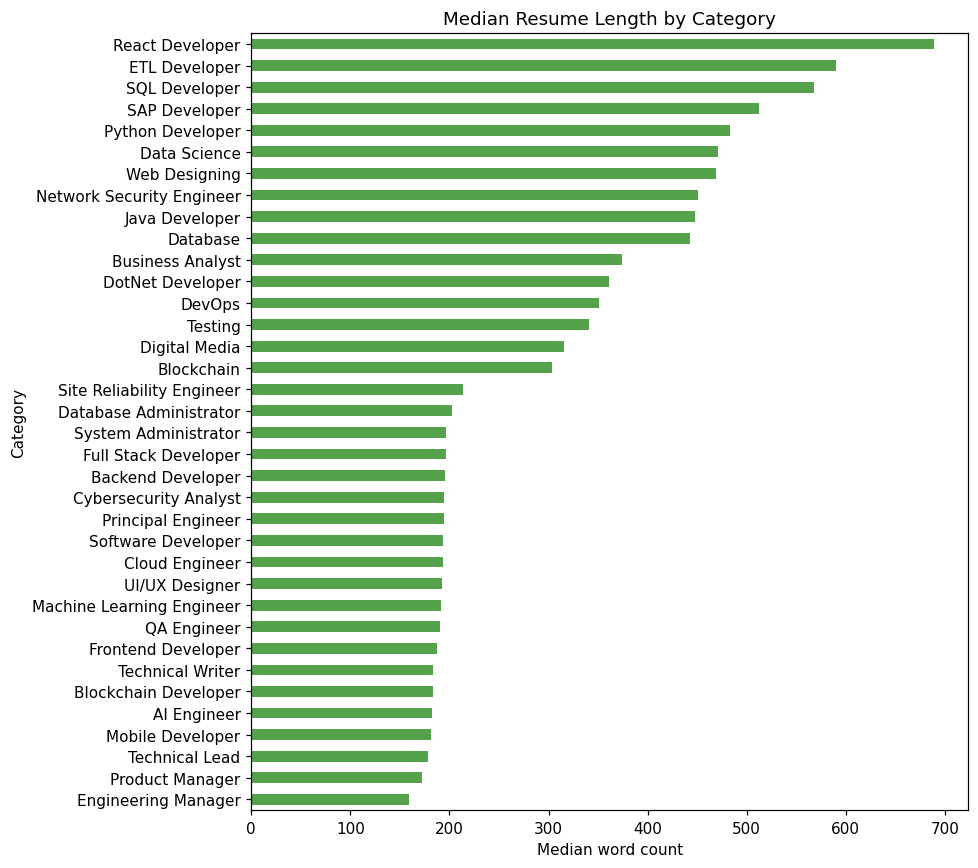

In [10]:
med = df.groupby('Category')['text_len_words'].median().sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
med.plot(kind='barh', ax=ax, color='#54A24B')
ax.set_xlabel('Median word count')
ax.set_title('Median Resume Length by Category')
plt.tight_layout()
plt.savefig('../reports/figures/04_median_length_by_category.png')
plt.show()


## 7. Skill Frequency (Synthetic subset — the only reliable structured Skills field)

In [11]:
synth = df[df['Source'] == 'Synthetic']
skill_counter = Counter()
for s in synth['Skills']:
    for skill in s.split(','):
        skill = skill.strip()
        if skill:
            skill_counter[skill] += 1

print(f"{len(skill_counter)} distinct skills across {len(synth)} synthetic resumes")
top_skills = pd.Series(dict(skill_counter.most_common(20)))
top_skills


95 distinct skills across 1163 synthetic resumes


Git              905
Python           709
Linux            668
Docker           657
AWS              641
Agile            613
SQL              609
JavaScript       555
REST API         408
Scrum            351
Microservices    344
PostgreSQL       336
Node.js          319
React            292
Java             292
MongoDB          271
HTML             169
Express          166
CSS              165
GCP              163
dtype: int64

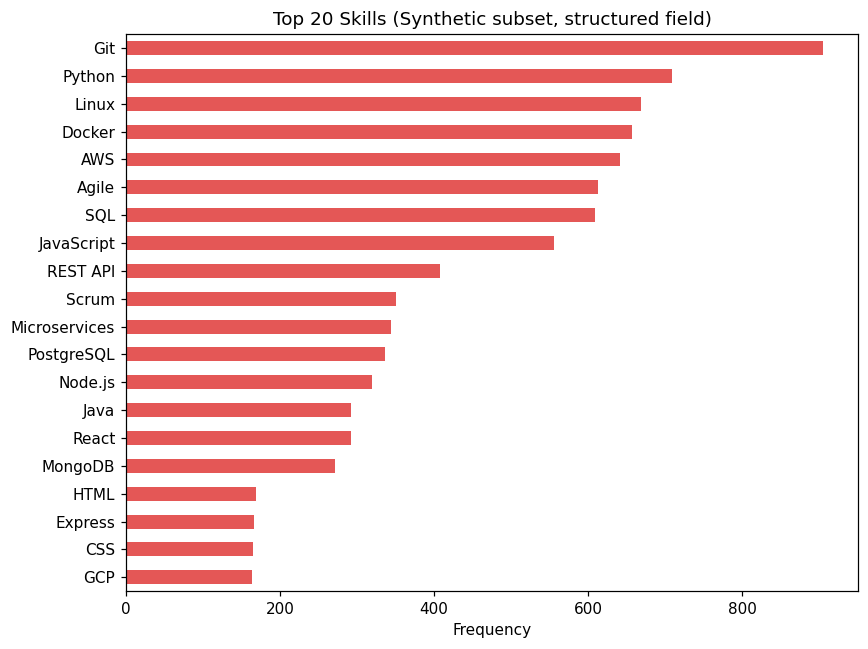

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
top_skills.sort_values().plot(kind='barh', ax=ax, color='#E45756')
ax.set_title('Top 20 Skills (Synthetic subset, structured field)')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('../reports/figures/05_top_skills_synthetic.png')
plt.show()


## 8. Word Frequency Across All Resume Text

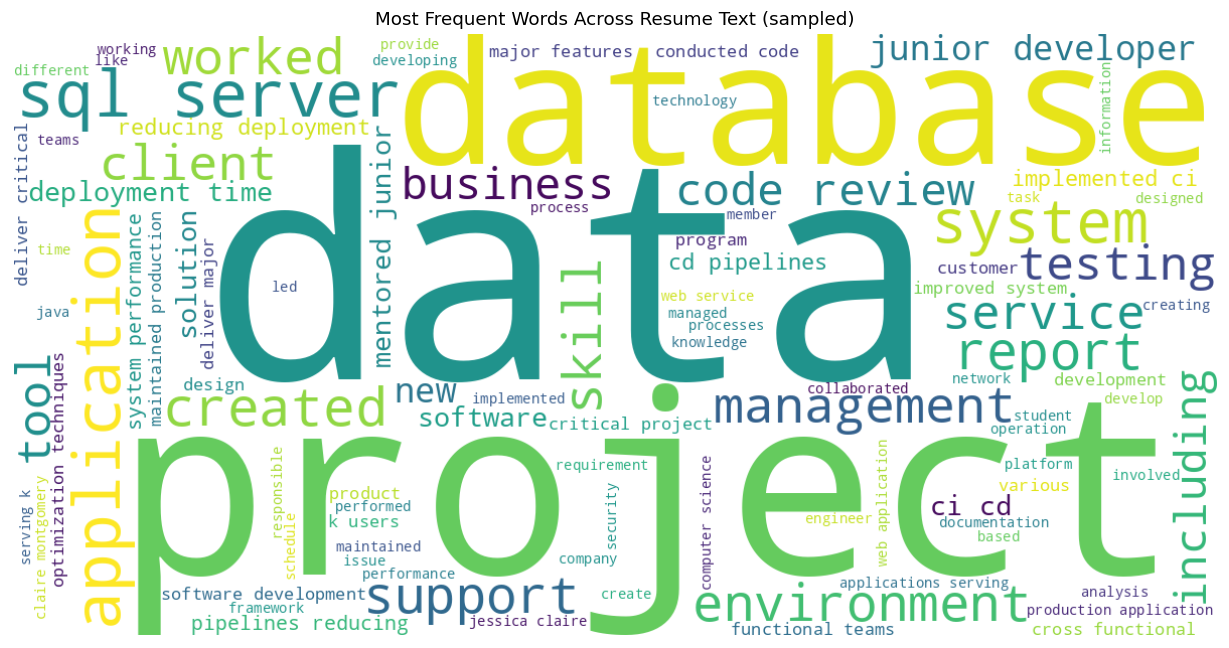

In [13]:
stop_words = set(stopwords.words('english'))
stop_words |= {'city', 'state', 'current', 'experience', 'team', 'work',
               'years', 'developed', 'using', 'used'}

sample_text = ' '.join(df['Text'].sample(min(800, len(df)), random_state=42))
sample_text = re.sub(r'[^a-zA-Z\s]', ' ', sample_text.lower())

wc = WordCloud(width=1200, height=600, background_color='white',
               stopwords=stop_words, max_words=100, colormap='viridis').generate(sample_text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Frequent Words Across Resume Text (sampled)')
plt.tight_layout()
plt.savefig('../reports/figures/06_wordcloud.png')
plt.show()


## 9. Education & Experience Distribution (Synthetic subset)

In [14]:
degree_pattern = r"(Bachelor|Master|PhD|Associate)[^,]*"
synth = synth.copy()
synth['degree_level'] = synth['Education'].str.extract(degree_pattern, expand=False)
synth['degree_level'].value_counts().head(15)


degree_level
Bachelor    712
Master      451
Name: count, dtype: int64

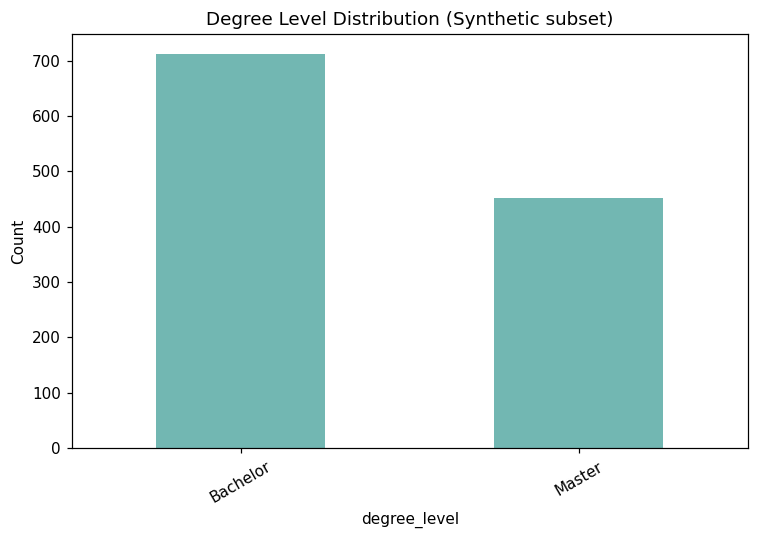

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
synth['degree_level'].str.split().str[0].value_counts().plot(kind='bar', ax=ax, color='#72B7B2')
ax.set_title('Degree Level Distribution (Synthetic subset)')
ax.set_ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/figures/07_degree_level.png')
plt.show()


## 10. Data Quality Summary

In [16]:
quality_report = {
    "total_records": len(df),
    "duplicate_resume_ids": int(df['ResumeID'].duplicated().sum()),
    "duplicate_text_rows": int(df['Text'].duplicated().sum()),
    "num_categories": int(df['Category'].nunique()),
    "sources": df['Source'].value_counts().to_dict(),
    "category_source_overlap": sorted(ra_cats & syn_cats),
    "resumeatlas_placeholder_fields": ["Skills", "Education", "Email", "Location"],
    "text_length_words": {
        "min": int(df['text_len_words'].min()),
        "median": int(df['text_len_words'].median()),
        "mean": round(float(df['text_len_words'].mean()), 1),
        "max": int(df['text_len_words'].max()),
    },
}
quality_report


{'total_records': 3500,
 'duplicate_resume_ids': 0,
 'duplicate_text_rows': 196,
 'num_categories': 36,
 'sources': {'ResumeAtlas': 2337, 'Synthetic': 1163},
 'category_source_overlap': [],
 'resumeatlas_placeholder_fields': ['Skills',
  'Education',
  'Email',
  'Location'],
 'text_length_words': {'min': 28, 'median': 257, 'mean': 423.6, 'max': 6554}}

## 11. Save EDA-pass Dataset

No real cleaning yet (that's# ) — this just flags duplicates and tags each row with useful EDA-derived columns for downstream reuse.

In [17]:
df_out = df.copy()
df_out['is_duplicate_text'] = df_out['Text'].duplicated(keep='first')
df_out['skills_field_reliable'] = df_out['Source'] == 'Synthetic'

df_out.to_csv('../data/processed/resumes_eda_pass.csv', index=False)
print("Saved:", df_out.shape)


Saved: (3500, 16)


## 12. Summary of Findings

1. **3,500 resumes, 12 columns, 36 categories, no null values** — but nulls are the wrong thing to check;
   see finding 2.
2. **Two structurally different sources are merged together:** `ResumeAtlas` (2,337 rows) only has real
   data in `Text`; `Skills`/`Education`/`Email`/`Location` are copy-pasted placeholders. `Synthetic`
   (1,163 rows) has genuinely diverse structured fields.
3. **Category and Source are fully confounded** — zero overlap in categories between the two sources.
   Any classifier trained on this data risks learning source style, not job-category content, unless
   this is explicitly controlled for.
4. **Resume length differs sharply by source**: ResumeAtlas resumes are long and highly variable
   (mean ~540 words, max 6,554); Synthetic resumes are short and uniform (mean ~190 words). This is
   another leak-prone signal.
5. **196 resumes share identical `Text`** with another row — needs deduplication policy in# .
6. **Top real skills** (from the Synthetic subset): Git, Python, Linux, Docker, AWS, Agile, SQL,
   JavaScript, REST API, Scrum.
7. **Category class imbalance** is significant: largest classes (Java/Python Developer, Data Science)
   have 200 resumes; smallest (Technical Writer) has 20 — a 10x imbalance that# must handle
   (e.g. class weighting, stratified splits, macro-F1 as the primary metric).

## Next Module

**# — Data Cleaning & Feature Engineering.** Priorities carried over from this EDA:
- Deduplicate the 196 identical-`Text` rows (decide: drop, or keep with a flag).
- Treat `Skills`/`Education`/`Location`/`Email` as unreliable for ResumeAtlas rows; extract structured
  info from `Text` instead, or engineer a `has reliable structured fields` feature.
- Normalize resume length differences (e.g. truncation/padding strategy) so length doesn't dominate
  downstream embeddings or TF-IDF vectors.
- Build stratified train/test splits that respect the category imbalance and are aware of the
  source/category confound.


# 02 — Data Cleaning & Feature Engineering
### AI-Powered Intelligent Hiring Assistant —# 
**Goal:** Turn the raw, EDA-audited dataset into a clean, feature-rich, split dataset ready for
# (Resume Classification) and reusable by every later module (semantic matching, ranking,
parsing, RAG).

**Input:** `data/processed/resumes eda pass.csv` (# output)

This notebook is a thin orchestration layer — all real logic lives in reusable modules under
`src/preprocessing/` so Modules 3–9 can import the same functions instead of duplicating code:
- `text cleaner.py` — unicode/HTML/URL/punctuation cleaning
- `feature engineering.py` — spaCy NLP + numeric feature engineering + skill extraction
- `tfidf pipeline.py` — TF-IDF vectorizer build/fit/save/load
- `encoding.py` — label encoder build/fit/save/load
- `preprocess.py` — the full pipeline end-to-end (this notebook calls the same functions it does)


## 1. Load# Output & Generate Preprocessing Summary

In [1]:
import sys
sys.path.append('../src/preprocessing')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from text_cleaner import clean_resume_text_series, clean_resume_text
from feature_engineering import engineer_numeric_features, lemmatize_text, extract_skills_from_text
from tfidf_pipeline import build_tfidf_vectorizer, fit_transform_tfidf, save_vectorizer, top_terms_for_document
from encoding import fit_label_encoder, encode_labels, save_label_encoder

from sklearn.model_selection import train_test_split

pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/processed/resumes_eda_pass.csv')
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns (Module 1 output)")
df.head(3)


Loaded 3,500 rows, 16 columns (Module 1 output)


,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source,text_len_words,text_len_chars,is_duplicate_text,skills_field_reliable
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 2014 102011...,"City, State",jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom profe...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom profe...,Computer Science degree,jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom profe...,ResumeAtlas,204,1589,False,False
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 30 70 ...,"City, State",jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagma...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagma...,Computer Science degree,jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagma...,ResumeAtlas,212,1727,False,False
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 2 052017 2 5 2...,"City, State",jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 sum...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 sum...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 sum...,ResumeAtlas,722,5608,False,False


In [2]:
print("Preprocessing summary (pre-cleaning):")
print(f"  Total rows: {len(df):,}")
print(f"  Duplicate Text rows (from Module 1 flag): {df['is_duplicate_text'].sum()}")
print(f"  Rows with unreliable structured fields (ResumeAtlas): {(~df['skills_field_reliable']).sum()}")
print(f"  Categories: {df['Category'].nunique()}")


Preprocessing summary (pre-cleaning):
  Total rows: 3,500
  Duplicate Text rows (from Module 1 flag): 196
  Rows with unreliable structured fields (ResumeAtlas): 2337
  Categories: 36


## 2. Deduplicate Resumes

# flagged 196 rows with duplicate `Text`. Before deciding remove-vs-merge, we need to check
whether duplicated text shares the same label — if not, this isn't just redundancy, it's **label
noise**.

In [3]:
dup_groups = df[df.duplicated('Text', keep=False)].groupby('Text')

same_label_groups, conflicting_label_groups = 0, 0
same_label_rows, conflicting_label_rows = 0, 0
for text, g in dup_groups:
    if g['Category'].nunique() == 1:
        same_label_groups += 1
        same_label_rows += len(g)
    else:
        conflicting_label_groups += 1
        conflicting_label_rows += len(g)

print(f"Same-text, same-label groups: {same_label_groups} ({same_label_rows} rows)")
print(f"Same-text, CONFLICTING-label groups: {conflicting_label_groups} ({conflicting_label_rows} rows)")


Same-text, same-label groups: 108 (227 rows)
Same-text, CONFLICTING-label groups: 67 (144 rows)


**Decision:**
- **Same-text, same-label groups** → pure redundancy → keep first occurrence, drop the rest.
- **Same-text, conflicting-label groups** (the exact same resume text labeled with two different
  categories, e.g. `Java Developer` vs `React Developer`) → the ground truth can't be trusted for
  either copy → **drop all rows in the group**.

This is stricter than a plain `drop duplicates()`, but it protects# from training on
contradictory labels for identical inputs.

In [4]:
def deduplicate(df: pd.DataFrame) -> pd.DataFrame:
    dup_groups = df[df.duplicated('Text', keep=False)].groupby('Text')
    conflicting_text = [text for text, g in dup_groups if g['Category'].nunique() > 1]

    n_before = len(df)
    df = df[~df['Text'].isin(conflicting_text)].copy()
    df = df.drop_duplicates(subset='Text', keep='first').copy()
    print(f"Dedup: {n_before} -> {len(df)} rows "
          f"(dropped {n_before - len(df)} total: "
          f"{conflicting_label_rows} label-conflicting + "
          f"{same_label_rows - same_label_groups} same-label redundant)")
    return df.reset_index(drop=True)

df = deduplicate(df)


Dedup: 3500 -> 3237 rows (dropped 263 total: 144 label-conflicting + 119 same-label redundant)


## 3. Handle Placeholder Values

# found ResumeAtlas rows (67% of the data) have placeholder, non-informative
`Skills`/`Education`/`Email`/`Location` fields. Rather than trust these columns, we:
1. Keep an explicit `structured fields reliable` flag (True only for Synthetic rows)
2. Extract skills directly from resume `Text` using regex (Section 6) — this becomes the reliable
   skill signal for ALL rows, not just Synthetic ones

In [5]:
df['structured_fields_reliable'] = df['Source'] == 'Synthetic'
print(df['structured_fields_reliable'].value_counts())


structured_fields_reliable
False    2074
True     1163
Name: count, dtype: int64


## 4. Text Cleaning

Using `text cleaner.clean resume text`: unicode normalization, HTML/URL removal, email masking, punctuation cleanup (technical characters like `C++`, `.NET` preserved), whitespace normalization, lowercasing.

In [6]:
# Demonstrate on one example before running on the full dataset
example_raw = df['Text'].iloc[0]
example_clean = clean_resume_text(example_raw)
print("RAW (first 300 chars):\n", example_raw[:300])
print("\nCLEANED (first 300 chars):\n", example_clean[:300])


RAW (first 300 chars):
 jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professional bringing 10 years software design development integration advanced knowledge java skills agile html xml jdbc tomcat work history senior jav

CLEANED (first 300 chars):
 jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professional bringing 10 years software design development integration advanced knowledge java skills agile html xml jdbc tomcat work history senior jav


In [7]:
df['clean_text'] = clean_resume_text_series(df['Text'])
print("Cleaning complete.")
df[['Text', 'clean_text']].head(2)


Cleaning complete.


,Text,clean_text
0,jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom profe...,jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom profe...
1,jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagma...,jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagma...


## 5. NLP Processing — Tokenization, Stopword Removal, Lemmatization (spaCy)

In [8]:
# Demonstrate on one example
example_lemmatized = lemmatize_text(example_clean)
print("CLEANED:\n", example_clean[:300])
print("\nLEMMATIZED (stopwords removed):\n", example_lemmatized[:300])


CLEANED:
 jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professional bringing 10 years software design development integration advanced knowledge java skills agile html xml jdbc tomcat work history senior jav

LEMMATIZED (stopwords removed):
 jessica claire montgomery street san francisco 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professional bring 10 year software design development integration advanced knowledge java skill agile html xml jdbc tomcat work history senior java develo


In [9]:
%%time
df['lemmatized_text'] = df['clean_text'].apply(lambda t: lemmatize_text(t))
print("Lemmatization complete.")


Lemmatization complete.
CPU times: user 2min 29s, sys: 2.38 s, total: 2min 31s
Wall time: 2min 32s


## 6. Feature Engineering

Numeric features (`char count`, `word count`, `sentence count`, `unique word count`,
`avg word length`) plus keyword-count features (`technical skill count`,
`education keyword count`, `experience keyword count`, `certification keyword count`,
`project keyword count`), and regex-based **skill extraction from raw text** — this is what replaces
the untrustworthy ResumeAtlas `Skills` column.

In [10]:
df = engineer_numeric_features(df, text_col='clean_text')
df[['ResumeID', 'Category', 'word_count', 'technical_skill_count',
    'education_keyword_count', 'experience_keyword_count', 'extracted_skills']].head(5)


,ResumeID,Category,word_count,technical_skill_count,education_keyword_count,experience_keyword_count,extracted_skills
0,REAL_0001,Java Developer,204,10,3,5,"java, javascript, html, linux, agile, scrum, sas, excel, vba, jdbc"
1,REAL_0002,Java Developer,212,1,0,3,java
2,REAL_0003,Java Developer,722,22,2,3,"python, java, javascript, typescript, sql, css, angular, nodejs, spring, docker, kubernetes, aws..."
3,REAL_0004,Java Developer,1665,22,4,6,"python, java, javascript, typescript, sql, html, css, react, angular, spring, git, linux, postgr..."
4,REAL_0005,Java Developer,497,4,3,5,"javascript, html, css, agile"


## 7. Label Encoding

In [11]:
label_encoder = fit_label_encoder(df['Category'])
df['category_encoded'] = encode_labels(label_encoder, df['Category'])
print(f"{len(label_encoder.classes_)} classes encoded")
save_label_encoder(label_encoder, '../artifacts/label_encoder.pkl')


36 classes encoded


## 8. Stratified Train/Test Split

**Why stratification matters here specifically:**# found up to a 10x class imbalance across
36 categories (200 resumes for Java Developer vs 20 for Technical Writer), *and* a full
Source/Category confound. A random (non-stratified) split risks under-representing small classes in
the test set — or in the worst case, having zero test examples for the smallest classes — which would
make# 's evaluation metrics unreliable. Stratified splitting guarantees every category keeps
the same proportion in train and test.

In [12]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['category_encoded']
)
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

# Verify class proportions match closely between splits
train_prop = train_df['Category'].value_counts(normalize=True)
test_prop = test_df['Category'].value_counts(normalize=True)
max_drift = (train_prop - test_prop).abs().max()
print(f"Max class-proportion drift between train/test: {max_drift:.4f}")


Train: 2589 rows | Test: 648 rows
Max class-proportion drift between train/test: 0.0011


## 9. TF-IDF Pipeline

Fit **only on the training set** to avoid test-set leakage. `ngram range=(1,2)` captures both single skills (`python`) and bigrams (`machine learning`, `rest api`).

In [13]:
vectorizer = build_tfidf_vectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, max_df=0.9)
X_train_tfidf = fit_transform_tfidf(vectorizer, train_df['lemmatized_text'])
X_test_tfidf = vectorizer.transform(test_df['lemmatized_text'])

print(f"TF-IDF matrix shape — train: {X_train_tfidf.shape}, test: {X_test_tfidf.shape}")
save_vectorizer(vectorizer, '../artifacts/tfidf_vectorizer.pkl')


TF-IDF matrix shape — train: (2589, 5000), test: (648, 5000)


### 9.1 Quick sanity check: top TF-IDF terms for a sample resume

In [14]:
sample_idx = 0
sample_category = train_df['Category'].iloc[sample_idx]
top_terms = top_terms_for_document(vectorizer, X_train_tfidf[sample_idx], top_n=10)
print(f"Category: {sample_category}")
print("Top TF-IDF terms:", top_terms)


Category: Python Developer
Top TF-IDF terms: [('ansible', 0.13162202531270667), ('ftp', 0.11779145218054554), ('redhat', 0.11366758043534358), ('cloud watch', 0.11267201358457733), ('metal', 0.11239815184073662), ('dhcp', 0.1117188243554837), ('watch', 0.10748045335022569), ('justice', 0.10688008599677888), ('rhel', 0.10121247936500878), ('nagio', 0.09862673173185639)]


## 10. Save Outputs for# 

In [15]:
import json

df.to_csv('../data/processed/clean_resumes.csv', index=False)
train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

feature_metadata = {
    "n_raw_rows": 3500,
    "n_final_rows": len(df),
    "n_train": len(train_df),
    "n_test": len(test_df),
    "num_categories": int(df['Category'].nunique()),
    "tfidf_max_features": 5000,
    "tfidf_ngram_range": [1, 2],
    "numeric_feature_columns": [
        "char_count", "word_count", "sentence_count", "unique_word_count",
        "avg_word_length", "technical_skill_count", "education_keyword_count",
        "experience_keyword_count", "certification_keyword_count", "project_keyword_count",
    ],
    "text_column_for_tfidf": "lemmatized_text",
    "label_column_encoded": "category_encoded",
    "class_names": list(label_encoder.classes_),
}
with open('../artifacts/feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)

print("Saved: clean_resumes.csv, train.csv, test.csv, tfidf_vectorizer.pkl, label_encoder.pkl, feature_metadata.json")


Saved: clean_resumes.csv, train.csv, test.csv, tfidf_vectorizer.pkl, label_encoder.pkl, feature_metadata.json


## 11. Visualizations

### 11.1 Resume Length: Before vs After Cleaning

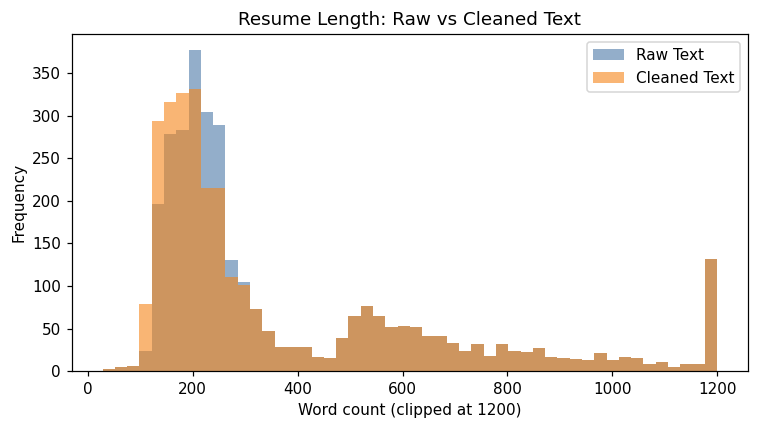

In [16]:
raw_word_count = df['Text'].str.split().str.len()  # note: df['Text'] still original raw column
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(raw_word_count.clip(upper=1200), bins=50, alpha=0.6, label='Raw Text', color='#4C78A8')
ax.hist(df['word_count'].clip(upper=1200), bins=50, alpha=0.6, label='Cleaned Text', color='#F58518')
ax.set_xlabel('Word count (clipped at 1200)')
ax.set_ylabel('Frequency')
ax.set_title('Resume Length: Raw vs Cleaned Text')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_length_before_after_cleaning.png')
plt.show()


### 11.2 Word Count Distribution (post-cleaning) by Source

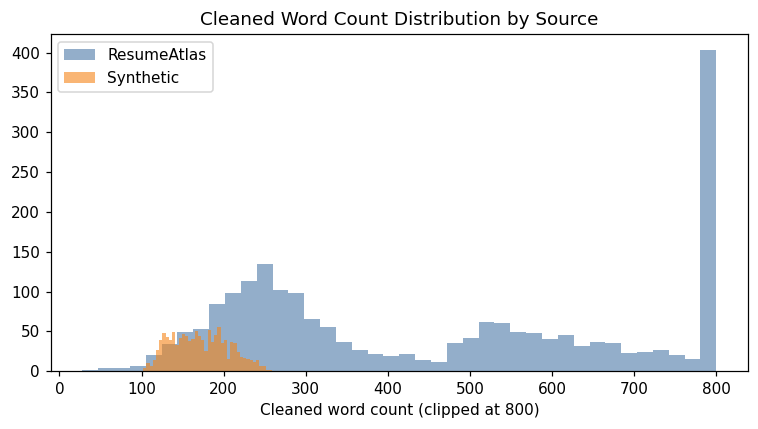

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
for src, color in [('ResumeAtlas', '#4C78A8'), ('Synthetic', '#F58518')]:
    sub = df[df.Source == src]['word_count']
    ax.hist(sub.clip(upper=800), bins=40, alpha=0.6, label=src, color=color)
ax.set_xlabel('Cleaned word count (clipped at 800)')
ax.set_title('Cleaned Word Count Distribution by Source')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/09_wordcount_distribution_cleaned.png')
plt.show()


### 11.3 Top Cleaned Vocabulary

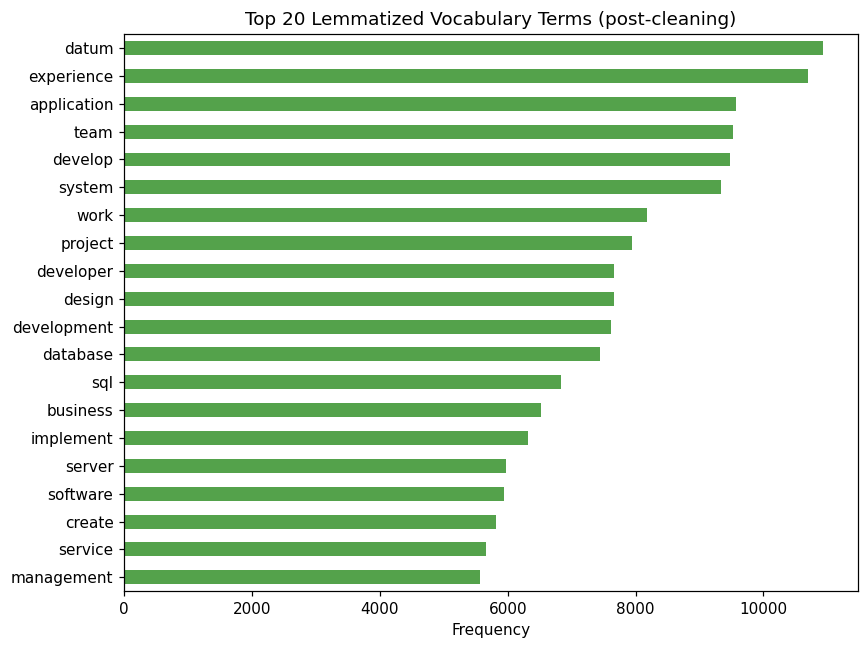

In [18]:
from collections import Counter
counter = Counter()
for t in df['lemmatized_text'].dropna():
    counter.update(t.split())
top20 = pd.Series(dict(counter.most_common(20)))

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='#54A24B')
ax.set_title('Top 20 Lemmatized Vocabulary Terms (post-cleaning)')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('../reports/figures/10_top_cleaned_vocabulary.png')
plt.show()


### 11.4 Category Balance After Split

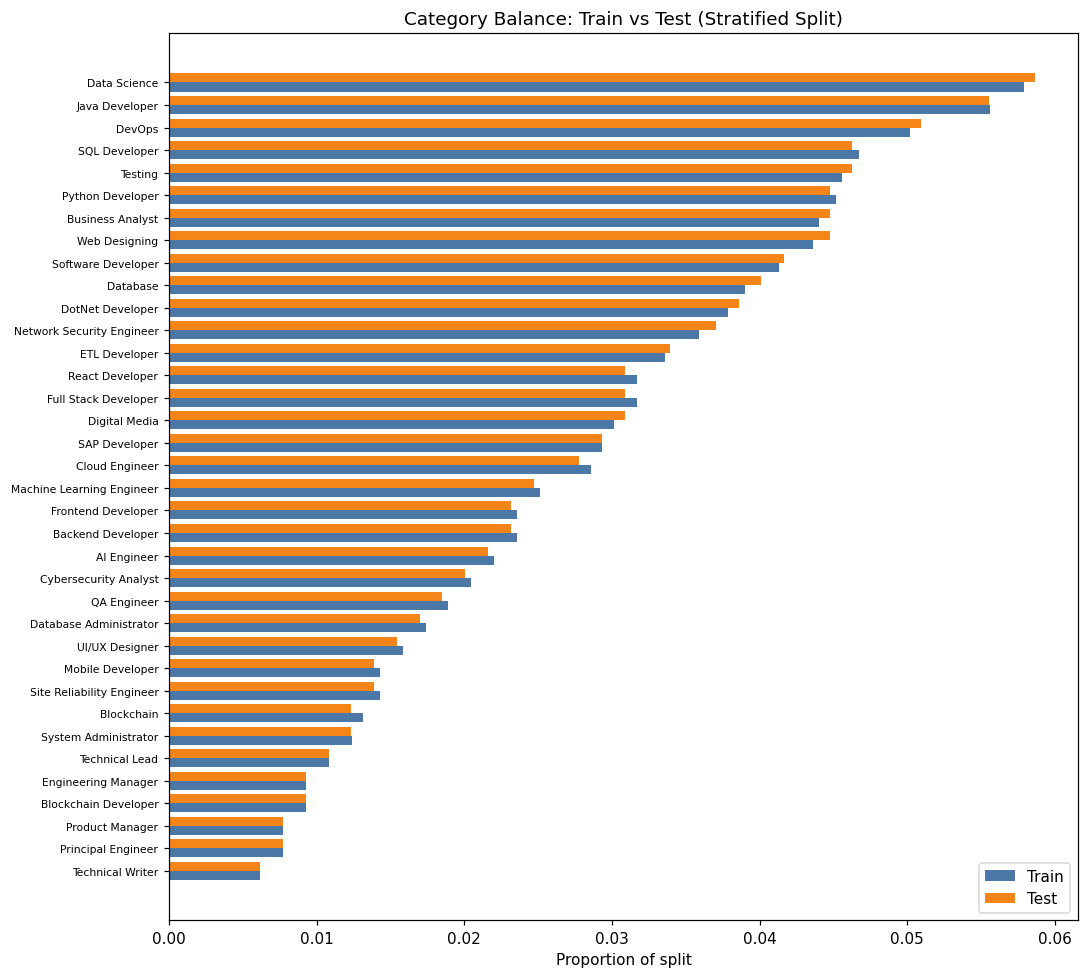

In [19]:
cats = train_df['Category'].value_counts(normalize=True).sort_values()
idx = cats.index
train_pct = train_df['Category'].value_counts(normalize=True).reindex(idx)
test_pct = test_df['Category'].value_counts(normalize=True).reindex(idx)

fig, ax = plt.subplots(figsize=(10, 9))
y = range(len(idx))
ax.barh([i - 0.2 for i in y], train_pct.values, height=0.4, label='Train', color='#4C78A8')
ax.barh([i + 0.2 for i in y], test_pct.values, height=0.4, label='Test', color='#F58518')
ax.set_yticks(list(y))
ax.set_yticklabels(idx, fontsize=7)
ax.set_xlabel('Proportion of split')
ax.set_title('Category Balance: Train vs Test (Stratified Split)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/11_category_balance_train_test.png')
plt.show()


### 11.5 TF-IDF Feature Importance (Sample)

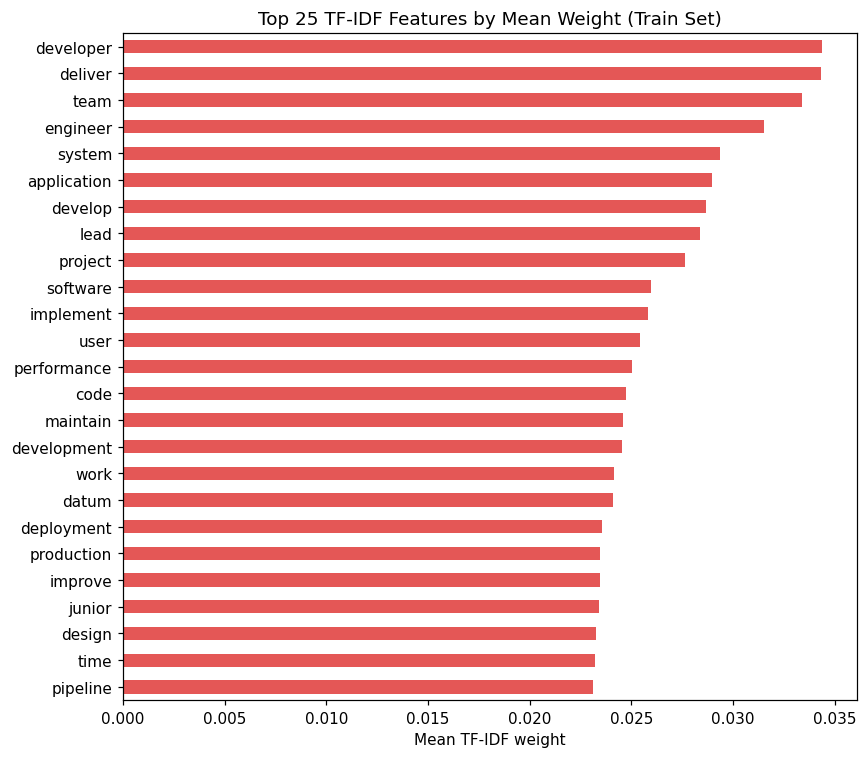

In [20]:
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
feature_names = vectorizer.get_feature_names_out()
top_idx = mean_tfidf.argsort()[::-1][:25]
top_terms_series = pd.Series(mean_tfidf[top_idx], index=feature_names[top_idx])

fig, ax = plt.subplots(figsize=(8, 7))
top_terms_series.sort_values().plot(kind='barh', ax=ax, color='#E45756')
ax.set_title('Top 25 TF-IDF Features by Mean Weight (Train Set)')
ax.set_xlabel('Mean TF-IDF weight')
plt.tight_layout()
plt.savefig('../reports/figures/12_tfidf_feature_importance.png')
plt.show()


## 12. Summary

### Preprocessing decisions
1. **Deduplication:** dropped 144 rows with label-conflicting duplicate text (untrustworthy ground
   truth), and 119 rows with same-label duplicate text (pure redundancy) — net 3,500 → 3,237 rows.
2. **Placeholder handling:** ResumeAtlas `Skills`/`Education`/`Email`/`Location` are flagged
   unreliable (`structured fields reliable=False`); a `technical skill count` and `extracted skills`
   feature is derived directly from resume text for every row instead.
3. **Text cleaning:** unicode/HTML/URL normalization, email masking, punctuation cleanup that
   preserves technical tokens (`C++`, `.NET`), lowercasing.
4. **NLP:** spaCy tokenization, stopword removal, lemmatization → `lemmatized text` (the TF-IDF input).
5. **Feature engineering:** 5 length-based + 5 keyword-count numeric features per resume.
6. **TF-IDF:** 5,000 features, unigrams+bigrams, fit on train only to prevent leakage.
7. **Label encoding:** fit on the full category set (not just train) to guarantee no unseen-label
   errors at inference time.
8. **Split:** stratified 80/20, max class-proportion drift 0.0011 — safe for a 36-class, imbalanced
   target.

### Files created
- `data/processed/clean resumes.csv`, `train.csv`, `test.csv`
- `artifacts/tfidf vectorizer.pkl`, `label encoder.pkl`, `feature metadata.json`
- `src/preprocessing/{preprocess,text cleaner,feature engineering,tfidf pipeline,encoding}.py`
- `reports/figures/08–12 *.png`
- `reports/Preprocessing Report.md`

### How this module improves the dataset
Removes 263 unreliable/duplicate rows, adds 10 structured numeric features plus a reliable
text-derived skill list for every resume regardless of source, and produces leakage-safe,
stratified, ML-ready train/test splits with saved artifacts# can load directly.

### Potential risks
- Regex-based skill extraction (`TECH SKILLS` list) is a fixed vocabulary — it will miss skills not
  in the list and can't yet handle synonyms (e.g. "Node" vs "Node.js" vs "NodeJS").
- The Source/Category confound from# is *not* removed by this module (dedup and cleaning
  don't fix it) —# must still evaluate with this in mind (e.g. macro-F1, per-source error
  analysis).
- spaCy lemmatization takes ~2–3 minutes for 3.2k resumes; this will need batching (`nlp.pipe`) if the
  dataset grows significantly.

### Recommendations for# - Use `category encoded` as the target, `train.csv`/`test.csv` as the splits, and the saved
  `tfidf vectorizer.pkl`/`label encoder.pkl` directly rather than refitting.
- Report macro-F1 alongside accuracy, and check whether misclassifications correlate with `Source`
  to confirm the model isn't just learning source style.
- Consider also feeding the 10 numeric engineered features (not just TF-IDF) into models like
  Random Forest/XGBoost that can combine sparse text features with dense numeric ones.
